In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
from scipy.stats import chi2_contingency

sns.set(style="whitegrid")

# Load cleaned dataset
df = pd.read_csv("CrimeDataCleaned.csv")

# Quick overview
df.info()
df.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004991 entries, 0 to 1004990
Data columns (total 35 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   DR_NO                1004991 non-null  int64  
 1   Date Rptd            1004991 non-null  object 
 2   DATE OCC             1004991 non-null  object 
 3   TIME OCC             1004991 non-null  object 
 4   AREA                 1004991 non-null  int64  
 5   AREA NAME            1004991 non-null  object 
 6   Rpt Dist No          1004991 non-null  int64  
 7   Part 1-2             1004991 non-null  int64  
 8   Crm Cd               1004991 non-null  int64  
 9   Crm Cd Desc          1004991 non-null  object 
 10  Mocodes              853372 non-null   object 
 11  Vict Age             1004991 non-null  object 
 12  Vict Sex             1004991 non-null  object 
 13  Vict Descent         1004991 non-null  object 
 14  Premis Cd            1004975 non-null  float64
 15

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Has_Multiple_Crimes,All_Crm_Cd,YEAR,MONTH,DAY_OF_WEEK,IS_WEEKEND,TIME_PERIOD,MoCodes_desc,Vict Descent Full,Part_Type
0,211507896,2021-04-11,2020-11-07,08:45,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,...,False,354,2020,11,Saturday,True,Unknown,Takes vict's identification/driver license,Hispanic/Latin/Mexican,Less Serious
1,201516622,2020-10-21,2020-10-18,18:45,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,False,230,2020,10,Sunday,True,Unknown,"Hit-Hit w/ weapon, Brandishes weapon, Suspect ...",Hispanic/Latin/Mexican,Serious
2,240913563,2024-12-10,2020-10-30,12:40,9,Van Nuys,933,2,354,THEFT OF IDENTITY,...,False,354,2020,10,Friday,False,Unknown,Takes vict's identification/driver license,White,Less Serious


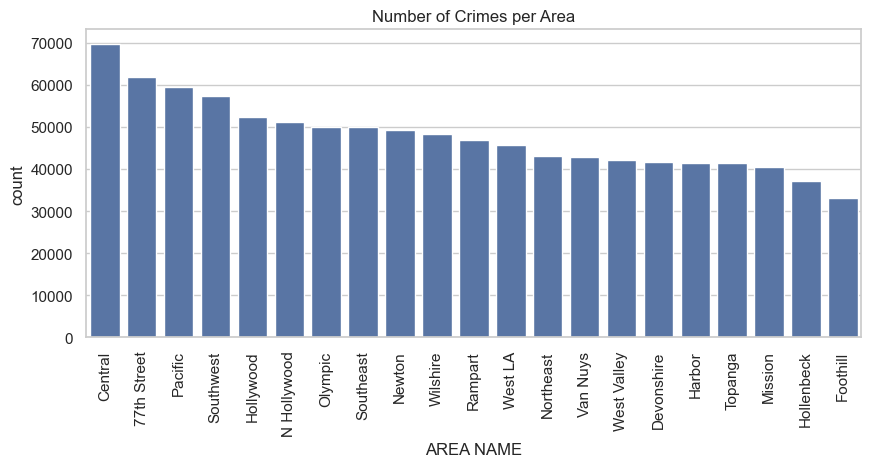

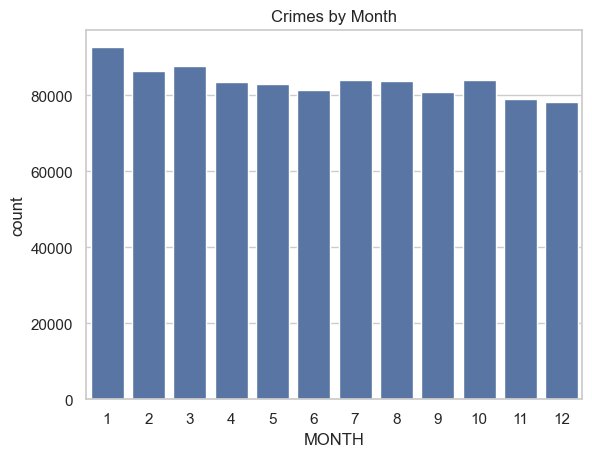

Peak month: 1 → 92701
Lowest month: 12 → 78226


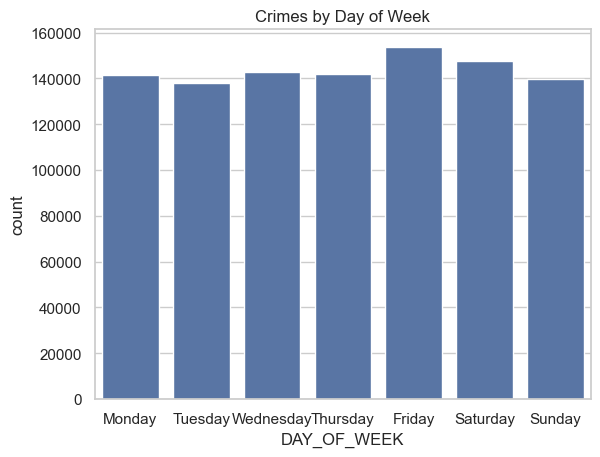

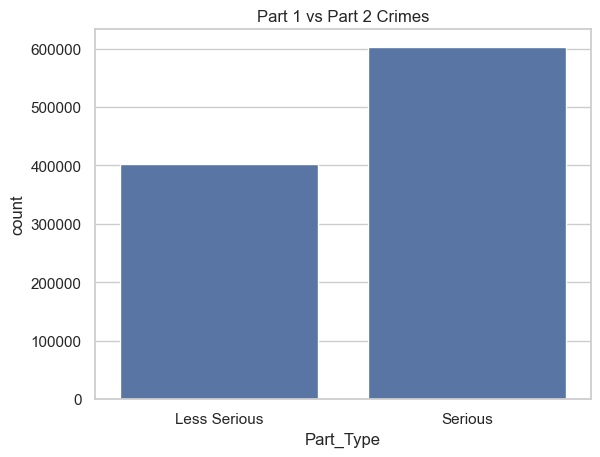

In [6]:
# 1) Crimes per Area
plt.figure(figsize=(10,4))
sns.countplot(data=df, x="AREA NAME", order=df["AREA NAME"].value_counts().index)
plt.xticks(rotation=90)
plt.title("Number of Crimes per Area")
plt.show()

# 2) Crimes by Month
sns.countplot(data=df, x="MONTH")
plt.title("Crimes by Month")
plt.show()

mon_counts = df["MONTH"].value_counts()
print("Peak month:", mon_counts.idxmax(), "→", int(mon_counts.max()))
print("Lowest month:", mon_counts.idxmin(), "→", int(mon_counts.min()))

# 3) Crimes by Day of Week
sns.countplot(data=df, x="DAY_OF_WEEK",
              order=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
plt.title("Crimes by Day of Week")
plt.show()

# 4) Part 1 vs Part 2 Crimes
sns.countplot(data=df, x="Part_Type")
plt.title("Part 1 vs Part 2 Crimes")
plt.show()

In [7]:
# --- Prepare numeric age & optional age groups ---

import numpy as np
import pandas as pd

# 1) Make numeric version of Vict Age
#    - strings like "Unknown" -> NaN
#    - 0, negative, >120 -> NaN (treat as invalid/unreported)
df["Vict Age Numeric"] = pd.to_numeric(df["Vict Age"], errors="coerce")
df.loc[(df["Vict Age Numeric"] <= 0) | (df["Vict Age Numeric"] > 120), "Vict Age Numeric"] = np.nan

# 2) (Optional) Age groups
bins   = [0, 12, 17, 25, 40, 65, 120]
labels = ["Child", "Teen", "Youth", "Adult", "Middle-aged", "Senior"]

df["Age_Group"] = pd.cut(df["Vict Age Numeric"], bins=bins, labels=labels, right=True)
# If you dislike 'Unknown', either leave NaN as-is, or fill with another label:
# df["Age_Group"] = df["Age_Group"].cat.add_categories(["Not Applicable"]).fillna("Not Applicable")

# 3) Quick sanity checks
print("Vict Age Numeric — non-null count:", df["Vict Age Numeric"].notna().sum())
print("Age_Group value counts:\n", df["Age_Group"].value_counts(dropna=False).head(10))


Vict Age Numeric — non-null count: 735632
Age_Group value counts:
 Age_Group
Adult          292637
NaN            269359
Middle-aged    253601
Youth          114074
Senior          49722
Teen            17294
Child            8304
Name: count, dtype: int64


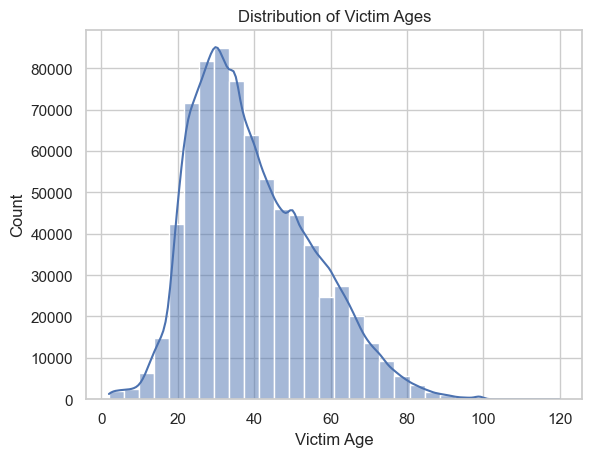

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["Vict Age Numeric"].dropna(), bins=30, kde=True)
plt.title("Distribution of Victim Ages")
plt.xlabel("Victim Age")
plt.show()

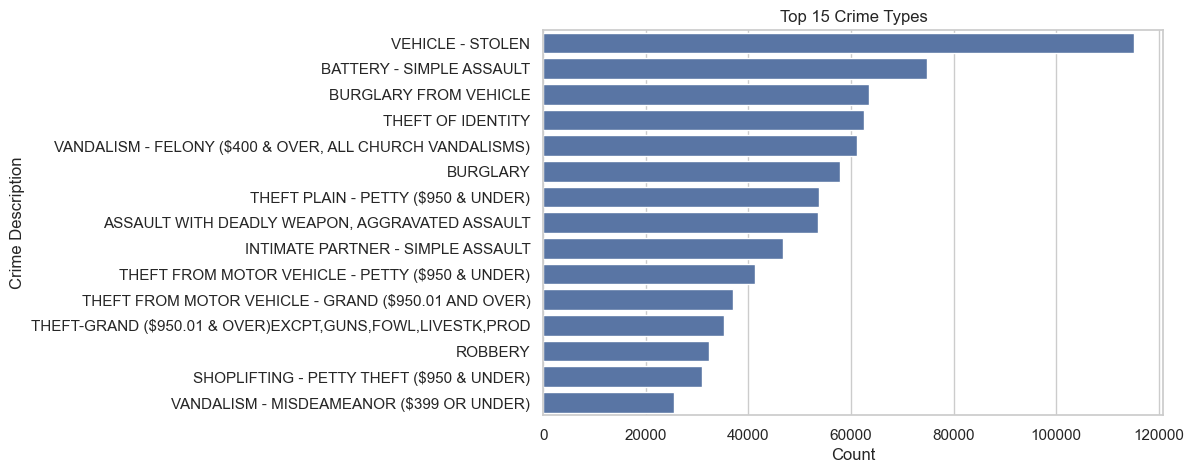

In [9]:
# Top 15 crime types
top15 = df["Crm Cd Desc"].value_counts().head(15)
plt.figure(figsize=(8,5))
sns.barplot(x=top15.values, y=top15.index)
plt.title("Top 15 Crime Types")
plt.xlabel("Count")
plt.ylabel("Crime Description")
plt.show()

In [10]:
df.to_csv("CrimeData_for_EDA.csv", index=False)
print("EDA-ready dataset saved.")

EDA-ready dataset saved.
